<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/ldakernel.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [183]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso: Análisis de datos                              #
# Tópico: Clasificador LDA kernel                       #
#########################################################

Carga bibliotecas necesarias

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [185]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Solo se utilizan dos clases

In [186]:
idx = (Y == 1) | (Y == 2) # Selecciona clases versicolor y virginica
X = X[idx.ravel(), :]
Y = Y[idx.ravel(), :]
Y[Y==2] = -1  # Asegura etiquetas -1 y +1
labels = iris.target_names[[1,2]] # Etiquetas de clase

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [187]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [188]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Funciones para entrenar y clasificar

In [194]:
def train(X,Y,gamma):
  # Asegura vectores columna
  X = X.T
  Y = Y.T
  # Cuenta número de muestras positivas y negativas
  Np = np.sum(Y == +1)
  Nm = np.sum(Y == -1)
  N  = Np + Nm
  # Indicadores para clases positivas y negativas
  Yp = (Y == +1).astype(float)
  Ym = (Y == -1).astype(float)
  # Construcción de matrices para el cálculo de pesos y bias
  B0 = np.diag(((2 * Np / N) * Yp + (2 * Nm / N) * Ym).flatten())
  B1 = ((2 * Nm) / (N * Np)) * (Yp == Yp.T).astype(float)
  B2 = ((2 * Np) / (N * Nm)) * (Ym == Ym.T).astype(float)
  B = B0 - B1 - B2
  # Kernel Gaussiano
  K = lambda X1, X2, g: np.exp(-gamma * cdist(X1.T, X2.T, 'sqeuclidean'))
  # Calcula la matriz del kernel para los datos de entrenamiento
  KX = K(X, X, gamma)
  # Calcular los coeficientes alfa usando pseudo-inversa
  alpha = np.linalg.pinv(B @ KX) @ Y.T
  # Calcula el vector e y el término de sesgo b
  e = ((1 / Np) * Yp + (1 / Nm) * Ym).T
  b = 0.5 * (alpha.T @ KX @ e)
  return alpha, b

def predict(X,Xt,alpha,b,gamma):
  X = X.T
  Xt = Xt.T
  # Elige el kernel
  K = lambda X1, X2, g: np.exp(-gamma * cdist(X1.T, X2.T, 'sqeuclidean'))
  Kt = K(X, Xt, gamma)
  gx = b - alpha.T @ Kt
  Y_pred = np.sign(gx)
  Y_pred = Y_pred.reshape(-1, 1)
  return Y_pred

Entrena y clasifica con LDA kernel

In [195]:
gamma = 0.5 # Ancho de banda del kernel Gaussiano
alphas, bias = train(X_train,Y_train,gamma)
Y_pred = predict(X_train,X_test,alphas, bias, gamma)

Visualiza matriz de confusión

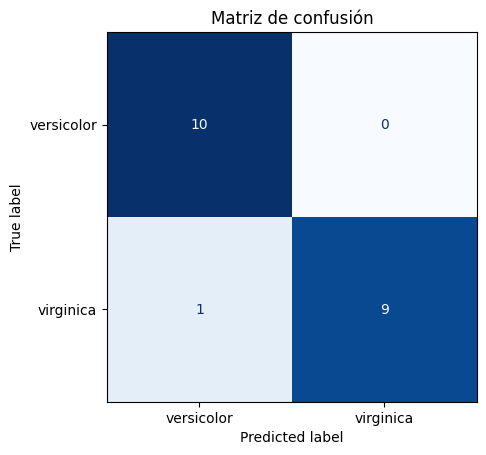

Exactitud: 0.950


In [191]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")